# Reducing GO Enrichment Redundancy with Semantic Similarity

## Overview

Gene Ontology (GO) enrichment analysis is a standard step in functional genomics, but the
hierarchical structure of GO means that enrichment results often contain highly redundant
terms — parent/child pairs, siblings, or semantically overlapping concepts that describe
essentially the same biology. This redundancy obscures the key biological themes and
complicates interpretation.

This notebook demonstrates an end-to-end pipeline using **go3** to:

1. **Quantify redundancy** in GO annotations for a real disease gene panel.
2. **Cluster semantically similar GO terms** and select non-redundant representatives.
3. **Compute gene-level functional similarity** to reveal pathway-level relationships.
4. **Visualize the functional landscape** of the gene panel via dimensionality reduction.

**Use case.** We use the [Genomics England PanelApp](https://panelapp.genomicsengland.co.uk/panels/39/)
gene panel for *Parkinson Disease and Complex Parkinsonism* (~36 genes) as a clinically
relevant example.

## 1. Setup and data loading

We load the GO ontology (`go-basic.obo`) and human gene annotations (GAF format) using go3.
Both files are standard resources maintained by the GO Consortium.

In [1]:
import csv
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform

import go3

# --- Paths (adjust to your environment) ---
ROOT = Path("..").resolve()
OBO_PATH = ROOT / "tests" / "go-basic.obo"
GAF_PATH = ROOT / "tests" / "goa_human.gaf"
PANEL_TSV = Path("Parkinson Disease and Complex Parkinsonism.tsv")

# --- Load ontology and annotations ---
go3.load_go_terms(str(OBO_PATH))
annotations = go3.load_gaf(str(GAF_PATH))
counter = go3.build_term_counter(annotations)

print(f"Loaded {len(annotations):,} GO annotations.")

Loaded 879,127 GO annotations.


## 2. Read the Parkinson Disease gene panel

The panel contains 36 genes curated by Genomics England for clinical genomic testing.
We extract gene symbols and filter to those with GO Biological Process (BP) annotations.

In [2]:
# Read gene symbols from the Genomics England panel
panel_genes = []
with open(PANEL_TSV, encoding="utf-8") as fh:
    reader = csv.DictReader(fh, delimiter="\t")
    for row in reader:
        if row.get("Entity type") == "gene":
            symbol = row.get("Gene Symbol", "").strip()
            if symbol:
                panel_genes.append(symbol)

panel_genes = sorted(set(panel_genes))
print(f"Panel genes ({len(panel_genes)}): {', '.join(panel_genes)}")

Panel genes (36): ATP13A2, ATP1A3, C19orf12, CSF1R, DCTN1, DNAJC6, FBXO7, FTL, GBA, GCH1, GRN, LRRK2, LYST, MAPT, OPA3, PANK2, PARK7, PDGFB, PINK1, PLA2G6, PRKN, PRKRA, PTRHD1, RAB39B, SLC30A10, SLC39A14, SLC6A3, SNCA, SPG11, SPR, SYNJ1, TH, TUBB4A, VPS13A, VPS35, WDR45


In [3]:
# Collect GO Biological Process annotations for each panel gene
NS = "biological_process"

gene2go_map = {}
with open(GAF_PATH, encoding="utf-8", errors="ignore") as fh:
    for line in fh:
        if line.startswith("!"):
            continue
        cols = line.rstrip("\n").split("\t")
        if len(cols) < 7:
            continue
        gene_symbol, qualifier, go_id, evidence = cols[2], cols[3], cols[4], cols[6]
        if evidence == "ND" or "NOT" in qualifier:
            continue
        if gene_symbol in panel_genes:
            gene2go_map.setdefault(gene_symbol, set()).add(go_id)

# Filter to BP namespace
gene_bp_terms = {}
for gene, terms in gene2go_map.items():
    bp = set()
    for go_id in terms:
        try:
            t = go3.get_term_by_id(go_id)
            if t.namespace == NS:
                bp.add(go_id)
        except Exception:
            continue
    if bp:
        gene_bp_terms[gene] = bp

genes_with_annot = sorted(gene_bp_terms.keys())
all_bp_terms = sorted({t for ts in gene_bp_terms.values() for t in ts})

print(f"Genes with BP annotations: {len(genes_with_annot)}/{len(panel_genes)}")
print(f"Total unique BP terms:     {len(all_bp_terms)}")

Genes with BP annotations: 34/36
Total unique BP terms:     678


## 3. Quantifying redundancy

With hundreds of GO terms, many are semantically overlapping. We compute all-vs-all pairwise
Lin similarity between the BP terms using `go3.batch_similarity()` and visualize the
distribution of similarity scores.

In [4]:
SIM_METHOD = "lin"

# Build all-vs-all similarity matrix using batch_similarity
n = len(all_bp_terms)
sim_matrix = np.zeros((n, n))
np.fill_diagonal(sim_matrix, 1.0)

list1, list2, indices = [], [], []
for i, j in combinations(range(n), 2):
    list1.append(all_bp_terms[i])
    list2.append(all_bp_terms[j])
    indices.append((i, j))

if list1:
    scores = go3.batch_similarity(list1, list2, SIM_METHOD, counter)
    for (i, j), s in zip(indices, scores):
        sim_matrix[i][j] = s
        sim_matrix[j][i] = s

upper = sim_matrix[np.triu_indices(n, k=1)]
print(f"Pairwise comparisons:      {len(upper):,}")
print(f"Mean similarity:           {upper.mean():.4f}")
print(f"Pairs with sim > 0.5:      {(upper > 0.5).sum():,} ({100*(upper > 0.5).mean():.1f}%)")
print(f"Pairs with sim > 0.7:      {(upper > 0.7).sum():,} ({100*(upper > 0.7).mean():.1f}%)")

Pairwise comparisons:      229,503
Mean similarity:           0.0564
Pairs with sim > 0.5:      3,530 (1.5%)
Pairs with sim > 0.7:      1,016 (0.4%)


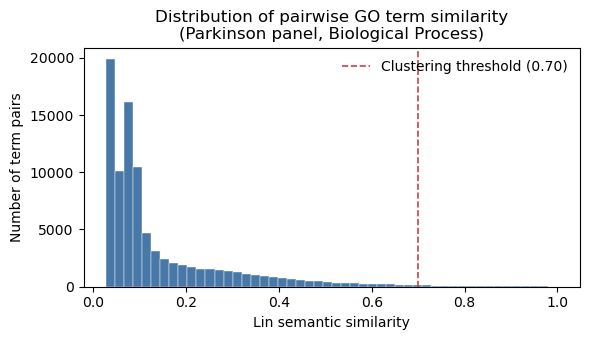

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(upper[upper > 0], bins=50, color="#4878A8", edgecolor="white", linewidth=0.3)
ax.axvline(0.7, color="#D04040", linestyle="--", linewidth=1.2, label="Clustering threshold (0.70)")
ax.set_xlabel("Lin semantic similarity")
ax.set_ylabel("Number of term pairs")
ax.set_title("Distribution of pairwise GO term similarity\n(Parkinson panel, Biological Process)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4. Clustering and redundancy reduction

We apply hierarchical clustering (average linkage) on the semantic distance matrix
(1 − similarity) and cut at a threshold of 0.70. For each cluster, the term with
the highest Information Content (IC) — i.e., the most specific — is selected as representative.

In [6]:
THRESHOLD = 0.70

# Hierarchical clustering
dist_matrix = np.clip(1.0 - sim_matrix, 0.0, None)
np.fill_diagonal(dist_matrix, 0.0)
condensed = squareform(dist_matrix, checks=False)
Z = linkage(condensed, method="average")
labels = fcluster(Z, t=1.0 - THRESHOLD, criterion="distance")

# Group terms by cluster
clusters = {}
for idx, cid in enumerate(labels):
    clusters.setdefault(int(cid), []).append(all_bp_terms[idx])

# Select representative per cluster (highest IC = most specific)
representatives = []
for cid, members in sorted(clusters.items()):
    best_id, best_ic = None, -1.0
    for go_id in members:
        ic = go3.term_ic(go_id, counter)
        if ic > best_ic:
            best_ic = ic
            best_id = go_id
    t = go3.get_term_by_id(best_id)
    representatives.append({
        "GO ID": best_id,
        "Name": t.name,
        "IC": round(best_ic, 3),
        "Cluster size": len(members),
    })

representatives.sort(key=lambda x: -x["IC"])

print(f"Original terms:       {len(all_bp_terms)}")
print(f"Non-redundant clusters: {len(representatives)}")
print(f"Reduction:            {100*(1 - len(representatives)/len(all_bp_terms)):.0f}%")

Original terms:       678
Non-redundant clusters: 350
Reduction:            48%


In [7]:
# Display the top 25 most specific non-redundant terms
df_reps = pd.DataFrame(representatives)
df_reps.index = range(1, len(df_reps) + 1)
df_reps.index.name = "#"
df_reps.head(25)

,GO ID,Name,IC,Cluster size
#,,,,
1,GO:1903073,negative regulation of death-inducing signalin...,10.359,1
2,GO:1905247,positive regulation of aspartic-type peptidase...,10.359,1
3,GO:1903197,positive regulation of L-dopa biosynthetic pro...,10.359,1
4,GO:0051622,negative regulation of norepinephrine uptake,10.359,2
5,GO:0051585,negative regulation of dopamine uptake involve...,10.359,4
6,GO:2000331,regulation of terminal button organization,10.359,2
7,GO:0035543,positive regulation of SNARE complex assembly,10.359,2
8,GO:0070994,detection of oxidative stress,10.359,1
9,GO:1904644,cellular response to curcumin,10.359,2


### Visualizing the clustering

The dendrogram below shows a subset of the largest multi-term clusters, illustrating how
semantically related GO terms are grouped together before representative selection.

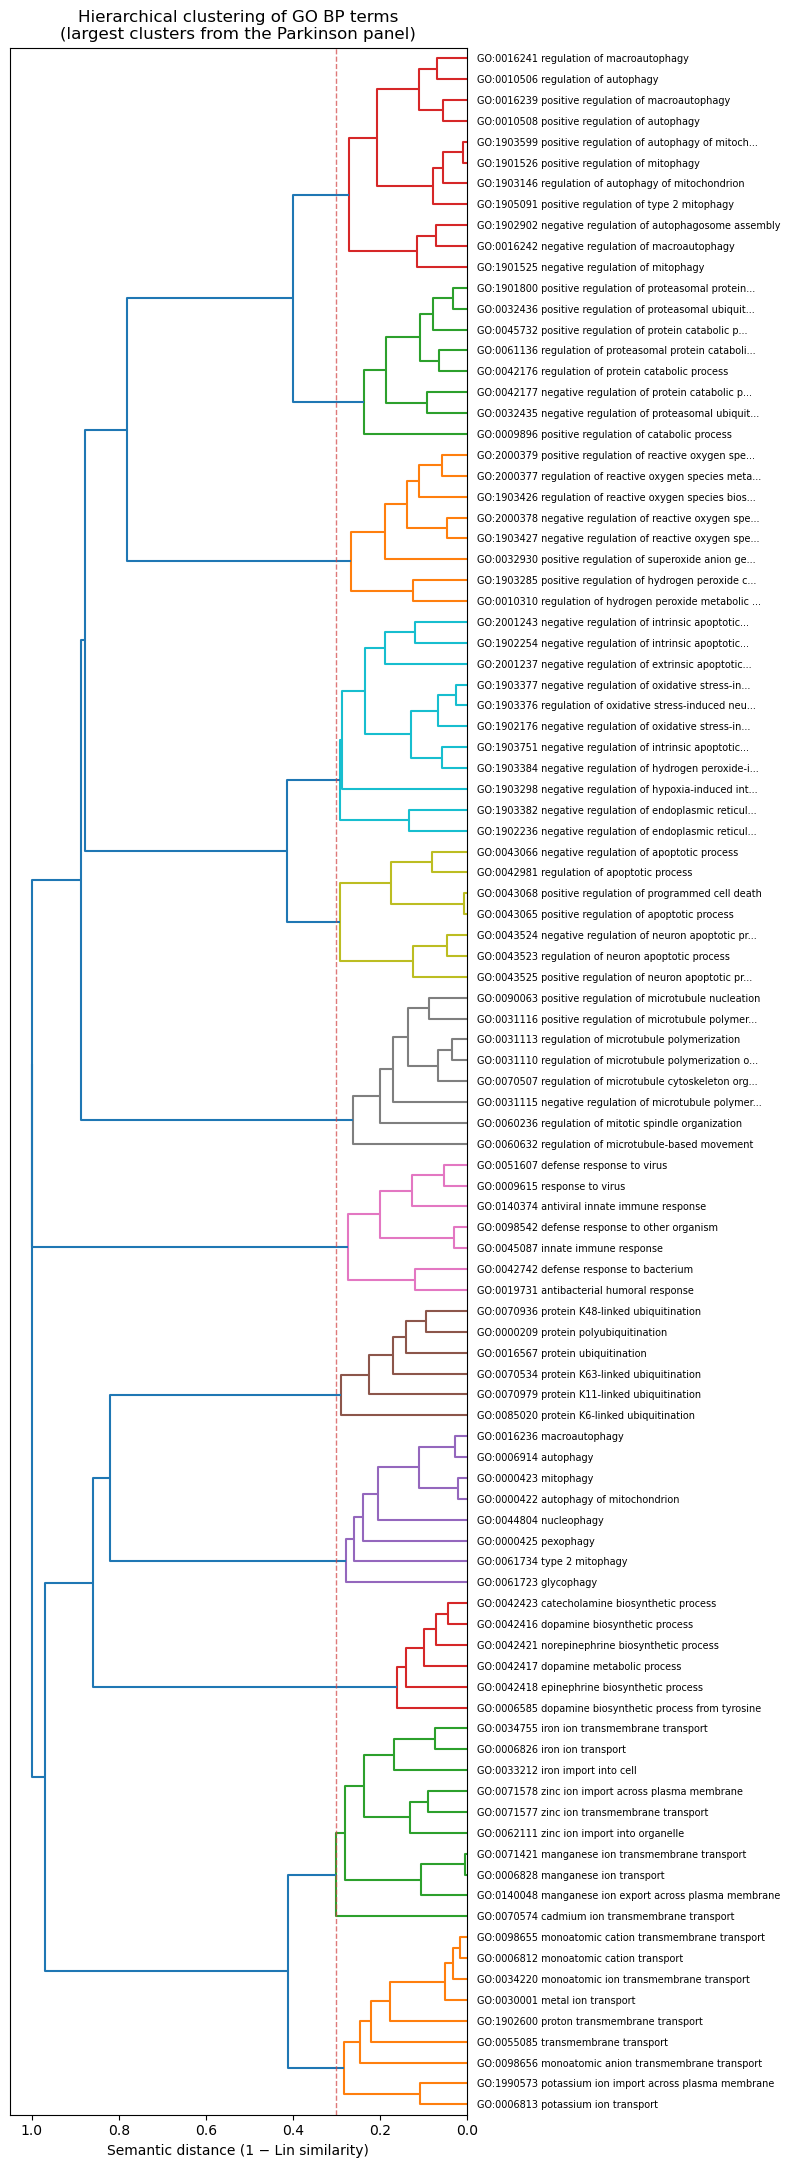

In [ ]:
# Select terms from the largest clusters for a readable dendrogram
large_clusters = sorted(clusters.items(), key=lambda x: -len(x[1]))
subset_terms = []
for _, members in large_clusters[:12]:  # top 12 largest clusters
    subset_terms.extend(members)

# Build sub-matrix and labels
sub_idx = [all_bp_terms.index(t) for t in subset_terms]
sub_dist = dist_matrix[np.ix_(sub_idx, sub_idx)]
sub_labels = []
for t in subset_terms:
    term_obj = go3.get_term_by_id(t)
    name = term_obj.name if len(term_obj.name) <= 45 else term_obj.name[:42] + "..."
    sub_labels.append(f"{t} {name}")

sub_condensed = squareform(sub_dist, checks=False)
sub_Z = linkage(sub_condensed, method="average")

fig, ax = plt.subplots(figsize=(8, max(5, len(subset_terms) * 0.22)))
dendrogram(
    sub_Z,
    labels=sub_labels,
    orientation="left",
    color_threshold=1.0 - THRESHOLD,
    leaf_font_size=7,
    ax=ax,
)
ax.axvline(1.0 - THRESHOLD, color="#D04040", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Semantic distance (1 − Lin similarity)")
ax.set_title("Hierarchical clustering of GO BP terms\n(largest clusters from the Parkinson panel)")
fig.tight_layout()
plt.show()

## 5. Gene-level functional similarity

Beyond term-level redundancy, go3 can compute functional similarity between genes
by comparing their full sets of GO annotations. We use `go3.gene_distance_matrix()` with
Lin similarity and Best Match Average (BMA) groupwise strategy to build a gene-by-gene
similarity matrix for the Parkinson panel.

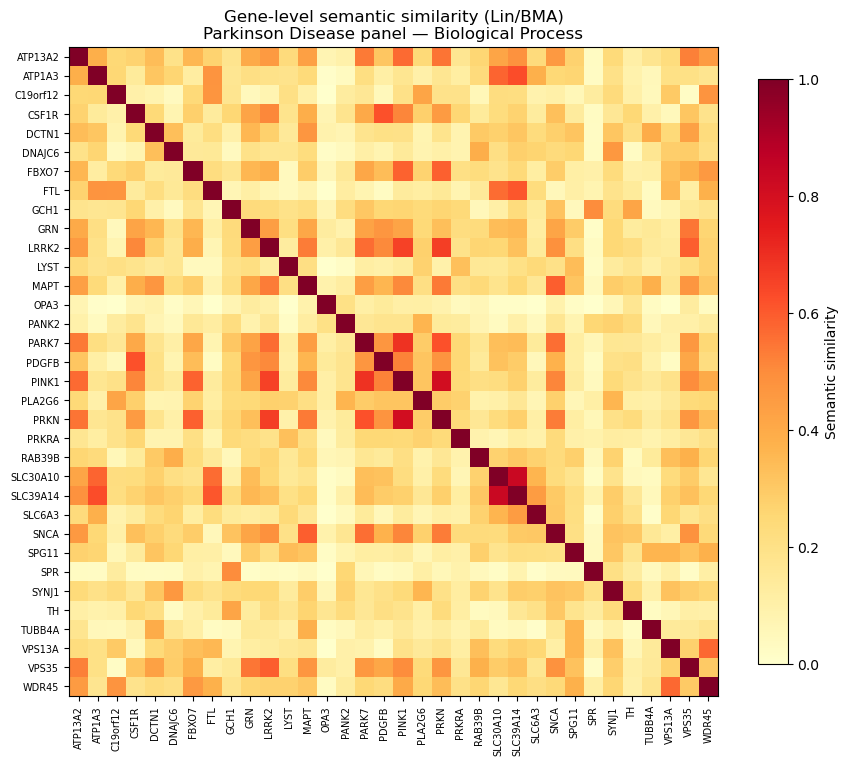

In [9]:
GROUPWISE = "bma"

ordered_genes, gene_dist = go3.gene_distance_matrix(
    genes=genes_with_annot,
    ontology="BP",
    similarity=SIM_METHOD,
    groupwise=GROUPWISE,
    counter=counter,
    distance_transform="one_minus",
)

# Convert to similarity for display
gene_sim = np.array([[1.0 - d for d in row] for row in gene_dist])
n_genes = len(ordered_genes)

# Show as heatmap
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(gene_sim, cmap="YlOrRd", vmin=0, vmax=1, aspect="equal")
ax.set_xticks(range(n_genes))
ax.set_yticks(range(n_genes))
ax.set_xticklabels(ordered_genes, rotation=90, fontsize=7)
ax.set_yticklabels(ordered_genes, fontsize=7)
ax.set_title("Gene-level semantic similarity (Lin/BMA)\nParkinson Disease panel — Biological Process")
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Semantic similarity")
fig.tight_layout()
plt.show()

In [10]:
# Top gene pairs by functional similarity
pairs = []
for i in range(n_genes):
    for j in range(i + 1, n_genes):
        pairs.append((ordered_genes[i], ordered_genes[j], gene_sim[i][j]))
pairs.sort(key=lambda x: -x[2])

df_pairs = pd.DataFrame(pairs[:15], columns=["Gene 1", "Gene 2", "Similarity"])
df_pairs.index = range(1, len(df_pairs) + 1)
df_pairs.index.name = "#"
df_pairs["Similarity"] = df_pairs["Similarity"].round(4)
df_pairs

,Gene 1,Gene 2,Similarity
#,,,
1,SLC30A10,SLC39A14,0.8346
2,PINK1,PRKN,0.8073
3,PARK7,PINK1,0.6900
4,LRRK2,PRKN,0.6617
5,LRRK2,PINK1,0.6531
6,ATP1A3,SLC39A14,0.6288
7,PARK7,PRKN,0.6207
8,CSF1R,PDGFB,0.6183
9,FTL,SLC39A14,0.6069


## 6. Functional landscape visualization (t-SNE)

We use go3's built-in t-SNE integration to project the gene distance matrix into two
dimensions, producing a functional map where genes with similar GO annotation profiles
are positioned close together.

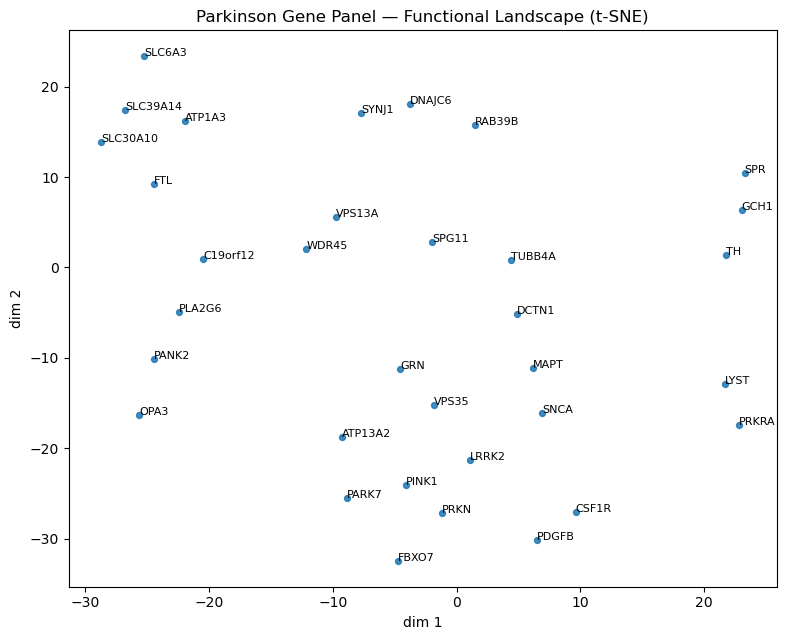

In [11]:
perplexity = min(8.0, max(2.0, (n_genes - 1) / 3.0))

ordered_genes_tsne, emb, fig, ax = go3.plot_tsne_genes(
    genes=genes_with_annot,
    ontology="BP",
    similarity=SIM_METHOD,
    groupwise=GROUPWISE,
    counter=counter,
    distance_transform="one_minus",
    perplexity=perplexity,
    n_iter=1000,
    random_state=42,
    annotate="all",
    title="Parkinson Gene Panel — Functional Landscape (t-SNE)",
)

fig.set_size_inches(8, 6.5)
fig.tight_layout()
plt.show()

## 7. Biological interpretation

The analysis reveals several functionally coherent groups within the Parkinson panel:

- **Mitophagy / mitochondrial quality control**: PINK1, PRKN, PARK7, FBXO7. These genes
  cluster tightly, consistent with the well-established PINK1/Parkin mitophagy pathway.
- **Metal ion transport**: SLC30A10, SLC39A14, FTL. Manganese and iron homeostasis genes
  show high mutual similarity, reflecting shared involvement in metal detoxification.
- **Dopamine biosynthesis**: GCH1, TH, SPR. Enzymes in the tetrahydrobiopterin/dopamine
  synthesis pathway cluster together.
- **Vesicle trafficking**: LRRK2, VPS35, SYNJ1, DNAJC6. Genes involved in synaptic vesicle
  and endosomal trafficking form a distinct functional group.
- **Growth factor signaling**: CSF1R, PDGFB. Receptor tyrosine kinase signaling genes.

The redundancy reduction step collapsed 678 GO terms into ~350 non-redundant clusters
(~48% reduction), highlighting that nearly half of the original annotations were
semantically overlapping. This demonstrates how go3 can produce a concise functional
summary from an otherwise overwhelming list of GO terms.